
주차수요 예측 AI 경진대회

[MIND, Private 3위, 100.3351] 다항회귀를 활용한 주차수요 예측

https://dacon.io/competitions/official/235745/codeshare/3017?page=1&dtype=recent

## 주제 및 문제점
유형별 임대주택 설계 시 단지 내 적정 🅿️ 주차 수요를 예측

## 데이터

train.csv - 학습용 데이터
단지코드
총세대수
임대건물구분
지역
공급유형
전용면적
전용면적별세대수
공가수
신분
임대료보증금
임대료
도보 10분거리 내 지하철역 수(환승노선 수 반영)
도보 10분거리 내 버스정류장 수
단지내주차면수
등록차량수

test.csv - 테스트 데이터

단지코드
총세대수
임대건물구분
지역
공급유형
전용면적
전용면적별세대수
공가수
신분
임대료보증금
임대료
도보 10분거리 내 지하철역 수(환승노선 수 반영)
도보 10분거리 내 버스정류장 수
단지내주차면수


age_gender_info.csv - 지역 임대주택 나이별, 성별 인구 분포

지역
10대미만(여자)
10대미만(남자)
20대(여자)
20대(남자)
30대(여자)
30대(남자)
40대(여자)
40대(남자)
50대(여자)
50대(남자)
60대(여자)
60대(남자)
70대(여자)
70대(남자)
80대(여자)
80대(남자)
90대(여자)
90대(남자)
100대(여자)
100대(남자)



## 코드 리뷰

### (1) EDA
- data 파악
- 데이터 타입 확인 : numberic/object
- 데이터 결측값 확인

### (2) Feature Engineering & Preprocessing
- '지하철/버스' -> 0으로 대체
- 파생변수 생성
    - 1) 등록 차량 수의 중앙값을 기준으로 지역을 5개의 지역으로 통합
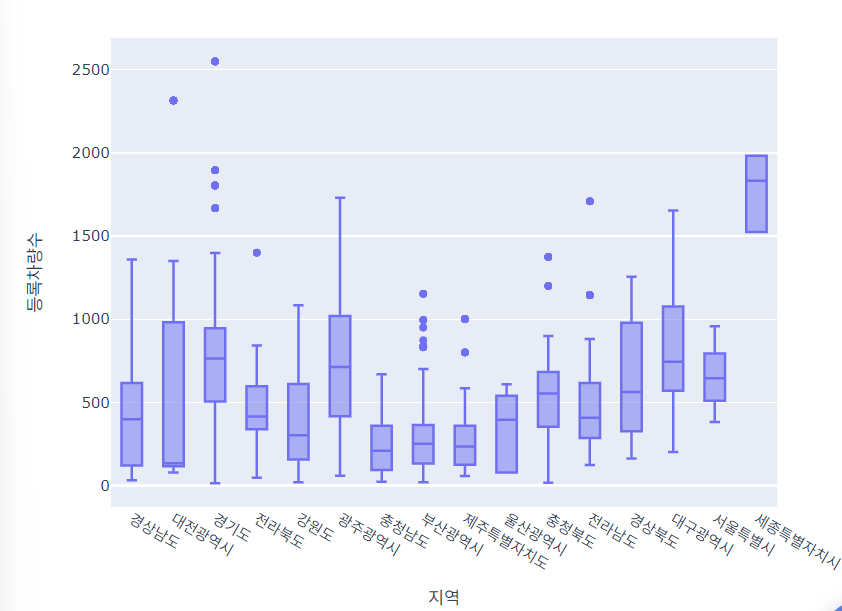
    - 2) 공급유형 : 등록차량수-단지내주차면수 차이를 기준으로 5개의 그룹을 통합
    - 3) 전용면적 : 5단위로 변환

### (3) 모델링
1) 단순회귀
  -  StandardScaler로 표준화 진행
    -> permutation importance를 이용하여 피처 중요도 검토

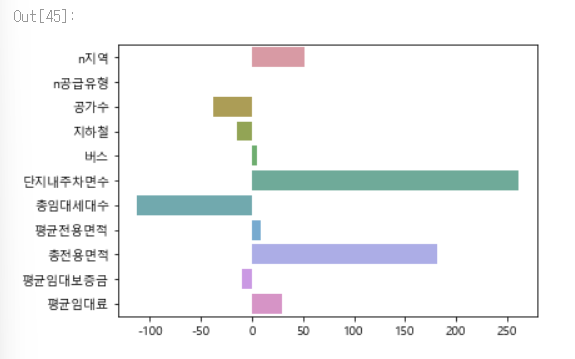


2) 다항회귀
  - 다중공산성, 회귀, permutation impotance로 최종 피처 선정
  - PolynomialFeatures를 클래스로 2차식으로 표현함

### (4) 모형 개선
1) 가중치 생성
  -Cook's Distance -> 각 관측값별 영향력 확인
  - 이를 바탕으로 Cook's Distance의 값이 작은 샘플에 큰 가중치를 부여함.
2) Stratified KFlold




## [차별점 및 배울점]
- 단순히 선형회귀와 다항회귀로 모델링에 멈추지 않고 이를 Cook's Distance를 이용해서 그 값을 바탕으로 가중치를 부여 수요 예측을 진행함
- EDA 과정에서 단순히 데이터 파악에 멈추지 않고 성능을 향상하기 위해서 다양한 파생변수들을 데이터 관계를 바탕으로 만들어감
- 위 코드 리뷰를 하면서 데이터 파생변수를 만들 때에 EDA를 바탕으로 데이터를 파악한 것을 바탕으로 파생변수를 만들어나가야 겠다고 생각함.